# Notebook unificado: datos RRSS donación de sangre

Carga, visualización exploratoria, limpieza y preprocesamiento por plataforma (Instagram, TikTok, Twitter, Reddit). En cada una se separan **emojis** y **texto**. Todo queda listo para un posterior análisis de sentimiento por fuente.

**Estructura:**
- Instagram: 1 CSV ya unificado → visualizaciones → limpieza → emojis/texto → guardar
- TikTok: unir todos los CSV → visualizaciones (timeline, etc.) → limpieza → emojis/texto → guardar
- Twitter: unir todos los CSV → visualizaciones → limpieza → emojis/texto → guardar
- Reddit: unir todos los CSV → quitar duplicados → visualizaciones → limpieza → emojis/texto → guardar

## 0. Configuración y utilidades

In [1]:
import pandas as pd
import numpy as np
import re
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Carpeta base del TFG (donde está este notebook)
BASE = Path(".").resolve()

### Función: separar emojis y texto

In [2]:
def split_emojis_text(s: str):
    """Devuelve (texto_sin_emojis, emojis_separados)."""
    if pd.isna(s) or not isinstance(s, str):
        return "", ""
    # Patrón para emojis (Unicode ranges comunes + símbolos)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001f926-\U0001f937"
        "\U00010000-\U0010ffff"
        "\u2600-\u26FF"
        "\u2700-\u27BF"
        "\uFE00-\uFE0F"
        "]+",
        flags=re.UNICODE
    )
    emojis = " ".join(emoji_pattern.findall(s))
    text = emoji_pattern.sub(" ", s)
    text = re.sub(r"\s+", " ", text).strip()
    return text, emojis

In [3]:
def add_text_emoji_columns(df, text_col="text"):
    """Añade columnas text_clean y emojis al DataFrame."""
    if text_col not in df.columns:
        return df
    texts, emojis = zip(*df[text_col].astype(str).map(split_emojis_text))
    df = df.copy()
    df["text_clean"] = list(texts)
    df["emojis"] = list(emojis)
    return df

---
## 1. Instagram
Cargamos el CSV unificado de comentarios de reels, exploramos y visualizamos, luego limpieza y división emojis/texto.

In [4]:
# Cargar Instagram (comentarios reels Apify)
path_ig = BASE / "Instagram" / "instagram_columnas_filtradas.csv"
df_ig = pd.read_csv(path_ig)
df_ig["fuente"] = "instagram"
# Fecha y métricas para análisis
df_ig["fecha"] = pd.to_datetime(df_ig["timestamp"], errors="coerce").dt.date
df_ig["likes"] = df_ig["likesCount"].fillna(0).astype(int)
df_ig["respuestas"] = df_ig["repliesCount"].fillna(0).astype(int)
print("Filas:", len(df_ig))
print("Columnas:", list(df_ig.columns))
df_ig.head()

Filas: 1368
Columnas: ['postUrl', 'id', 'text', 'timestamp', 'likesCount', 'repliesCount', 'ownerUsername', 'owner/full_name', 'owner/id', 'owner/is_verified', 'owner/is_private', 'fuente', 'fecha', 'likes', 'respuestas']


,postUrl,id,text,timestamp,likesCount,repliesCount,ownerUsername,owner/full_name,owner/id,owner/is_verified,owner/is_private,fuente,fecha,likes,respuestas
0,https://www.instagram.com/p/DRyD8WLAPoE/,18414420817136831,"Excelente video!! Fuerzas Jessi, comparto 🫂",2025-12-03T15:19:46.000Z,2,0,albavelazq,Alba velazquez,331434742,False,True,instagram,2025-12-03,2,0
1,https://www.instagram.com/p/DRyD8WLAPoE/,18210521863313862,Bendiciones familia!!!! Vamos Segun!!!💪💪,2025-12-03T01:36:57.000Z,4,0,esenciamiaropainformal,ESENCIA MÍA 👗 | Any Blanco,1960113903,False,False,instagram,2025-12-03,4,0
2,https://www.instagram.com/p/DRyD8WLAPoE/,17864457456531315,Compartido!!!! Vamos Segu❤️🙌,2025-12-03T10:19:52.000Z,2,0,maruvallet,Maru Vallet,3114282536,False,True,instagram,2025-12-03,2,0
3,https://www.instagram.com/p/DRyD8WLAPoE/,18094510561712976,Vamos amigos ! Ya saben cuánto los quiero ❤️,2025-12-04T01:33:53.000Z,2,0,alexiayaelc,Alexia Yael Caceres Baes,5494609535,False,True,instagram,2025-12-04,2,0
4,https://www.instagram.com/p/DRyD8WLAPoE/,18165615250391418,Compartido ❤️❤️❤️,2025-12-03T15:08:48.000Z,2,0,kinesiologiamujer,KIM | Kinesiología de Piso Pélvico para todxs,6269617973,False,False,instagram,2025-12-03,2,0


Posts únicos (post_url): 6


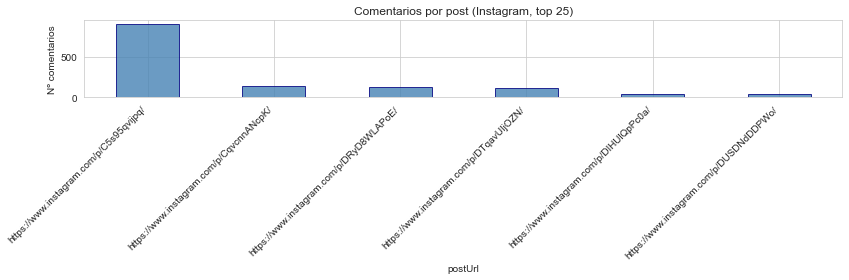

In [5]:
# Exploración: posts únicos y comentarios por post
print("Posts únicos (post_url):", df_ig["postUrl"].nunique())
comentarios_por_post = df_ig["postUrl"].value_counts()
fig, ax = plt.subplots(figsize=(12, 4))
comentarios_por_post.head(25).plot(kind="bar", ax=ax, color="steelblue", edgecolor="navy", alpha=0.8)
ax.set_title("Comentarios por post (Instagram, top 25)")
ax.set_ylabel("Nº comentarios")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# Limpieza básica Instagram: nulos, duplicados, texto vacío
df_ig = df_ig.dropna(subset=["text"])
df_ig["text"] = df_ig["text"].astype(str).str.strip()
df_ig = df_ig[df_ig["text"].str.len() > 0]
df_ig = df_ig.drop_duplicates(subset=["id"], keep="first")
print("Filas tras limpieza:", len(df_ig))

Filas tras limpieza: 1303


In [7]:
# Añadir columnas texto sin emojis y emojis
df_ig = add_text_emoji_columns(df_ig, text_col="text")
df_ig[["text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].head(10)

,text,text_clean,emojis,fecha,likes,respuestas
0,"Excelente video!! Fuerzas Jessi, comparto 🫂","Excelente video!! Fuerzas Jessi, comparto",🫂,2025-12-03,2,0
1,Bendiciones familia!!!! Vamos Segun!!!💪💪,Bendiciones familia!!!! Vamos Segun!!!,💪💪,2025-12-03,4,0
2,Compartido!!!! Vamos Segu❤️🙌,Compartido!!!! Vamos Segu,❤️🙌,2025-12-03,2,0
3,Vamos amigos ! Ya saben cuánto los quiero ❤️,Vamos amigos ! Ya saben cuánto los quiero,❤️,2025-12-04,2,0
4,Compartido ❤️❤️❤️,Compartido,❤️❤️❤️,2025-12-03,2,0
5,Un abrazo fuerte! 🙌❤️,Un abrazo fuerte!,🙌❤️,2025-12-03,2,0
6,Jesi! A donde nos podemos acercar para donar?,Jesi! A donde nos podemos acercar para donar?,,2025-12-03,2,1
7,Ya soy donante de médula desde el 2015!! Que l...,Ya soy donante de médula desde el 2015!! Que l...,,2025-12-03,4,0
8,Muchas fuerzas para toda la familia. Los que...,Muchas fuerzas para toda la familia. Los quere...,🤗🤗🤗,2025-12-03,4,0
9,"Hace unos 10 años que soy donante, si bien lo...","Hace unos 10 años que soy donante, si bien los...",,2025-12-03,31,3


In [8]:
# Guardar Instagram procesado
out_ig = BASE / "datos_procesados_instagram.csv"
df_ig.to_csv(out_ig, index=False, encoding="utf-8-sig")
print("Guardado:", out_ig)

Guardado: C:\Users\Usuario\OneDrive - Universidad Pontificia Comillas\SEXTO\TFG\datos_procesados_instagram.csv


Número total de comentarios Instagram: 1303


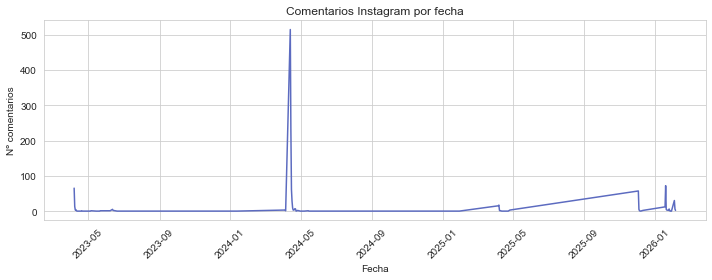

In [9]:
# Resumen Instagram: número total y distribución temporal
print(f"Número total de comentarios Instagram: {len(df_ig)}")
df_ig_ts = df_ig.dropna(subset=["fecha"]).copy()
por_fecha_ig = df_ig_ts.groupby("fecha").size()
fig, ax = plt.subplots(figsize=(10, 4))
por_fecha_ig.plot(ax=ax, color="#5c6bc0")
ax.set_title("Comentarios Instagram por fecha")
ax.set_ylabel("Nº comentarios")
ax.set_xlabel("Fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 2. TikTok
Unimos todos los CSV de la carpeta Tiktok (el del scraper tiene columnas en distinto orden: usamos text, videoWebUrl/submittedVideoUrl/input, createTimeISO). Luego visualizaciones temporales, limpieza y emojis/texto.

In [10]:
# Unificar todos los CSV de TikTok
carpeta_tiktok = BASE / "Tiktok"
csvs_tiktok = list(carpeta_tiktok.glob("*.csv"))
# El que tiene nombre dataset_tiktok-comments-scraper tiene columnas en otro orden
def leer_tiktok(path):
    df = pd.read_csv(path)
    # Estandarizar columnas: text, video_url, created_at
    if "text" not in df.columns:
        return None
    # video_url: videoWebUrl o submittedVideoUrl o input
    if "videoWebUrl" in df.columns:
        df["video_url"] = df["videoWebUrl"].astype(str)
    elif "submittedVideoUrl" in df.columns:
        df["video_url"] = df["submittedVideoUrl"].astype(str)
    elif "input" in df.columns:
        df["video_url"] = df["input"].astype(str)
    else:
        df["video_url"] = ""
    # created_at
    if "createTimeISO" in df.columns:
        df["created_at"] = pd.to_datetime(df["createTimeISO"], errors="coerce")
    elif "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
    elif "createTime" in df.columns:
        df["created_at"] = pd.to_datetime(df["createTime"], unit="s", errors="coerce")
    else:
        df["created_at"] = pd.NaT
    # likes y respuestas
    if "diggCount" in df.columns:
        df["likes"] = pd.to_numeric(df["diggCount"], errors="coerce").fillna(0).astype(int)
    else:
        df["likes"] = 0
    if "replyCommentTotal" in df.columns:
        df["respuestas"] = pd.to_numeric(df["replyCommentTotal"], errors="coerce").fillna(0).astype(int)
    else:
        df["respuestas"] = 0
    df["fecha"] = df["created_at"].dt.date
    return df[["text", "video_url", "created_at", "fecha", "likes", "respuestas"]].copy()

listas = []
for p in csvs_tiktok:
    try:
        d = leer_tiktok(p)
        if d is not None and len(d) > 0:
            d["_origen"] = p.name
            listas.append(d)
    except Exception as e:
        print("Error leyendo", p.name, e)
df_tiktok = pd.concat(listas, ignore_index=True)
df_tiktok["fuente"] = "tiktok"
print("Filas totales TikTok:", len(df_tiktok))
df_tiktok.head()

Filas totales TikTok: 897


,text,video_url,created_at,fecha,likes,respuestas,_origen,fuente
0,Q tiene q ver el piercing con donar sangre ?,https://www.tiktok.com/@_.naiaraa._21/video/73...,2023-12-09 20:45:17+00:00,2023-12-09,377,4,adolescente_donar_tiktok.csv,tiktok
1,"yo tmbn estoy en la d móstoles, dejan con tattos?",https://www.tiktok.com/@_.naiaraa._21/video/73...,2023-11-23 21:33:03+00:00,2023-11-23,105,4,adolescente_donar_tiktok.csv,tiktok
2,me quedé sola a traición,https://www.tiktok.com/@_.naiaraa._21/video/73...,2023-11-23 23:35:02+00:00,2023-11-23,257,1,adolescente_donar_tiktok.csv,tiktok
3,yo ahora que estoy dejando los vicios el tabac...,https://www.tiktok.com/@_.naiaraa._21/video/73...,2024-01-10 08:22:25+00:00,2024-01-10,1,0,adolescente_donar_tiktok.csv,tiktok
4,me acuerdo que está chica hacia videos con plex,https://www.tiktok.com/@_.naiaraa._21/video/73...,2024-01-15 01:18:53+00:00,2024-01-15,1,0,adolescente_donar_tiktok.csv,tiktok


Número total de comentarios TikTok: 897


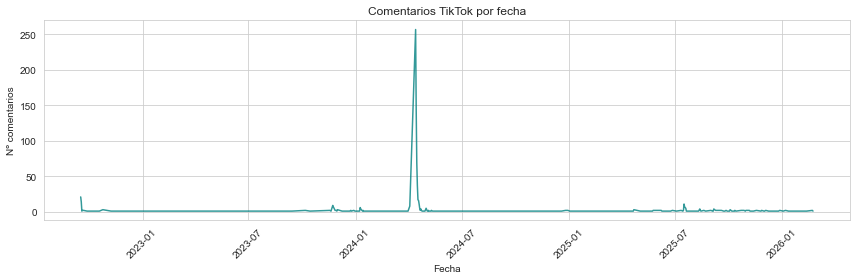

In [11]:
# Resumen TikTok: número total y distribución temporal
print(f"Número total de comentarios TikTok: {len(df_tiktok)}")
df_tiktok_ts = df_tiktok.dropna(subset=["created_at"]).copy()
df_tiktok_ts["fecha"] = df_tiktok_ts["created_at"].dt.date
por_fecha = df_tiktok_ts.groupby("fecha").size()
fig, ax = plt.subplots(figsize=(12, 4))
por_fecha.plot(ax=ax, color="teal", alpha=0.8)
ax.set_title("Comentarios TikTok por fecha")
ax.set_ylabel("Nº comentarios")
ax.set_xlabel("Fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

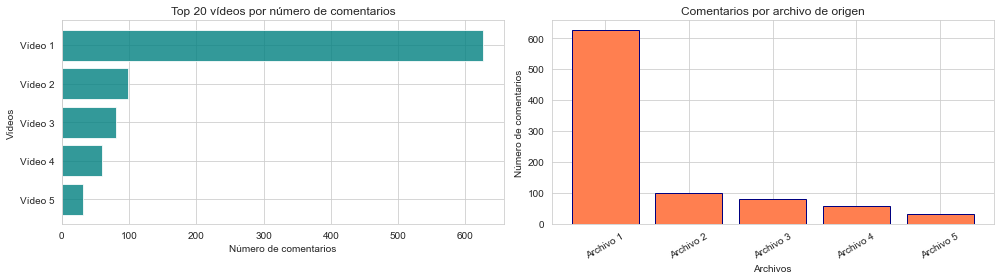

In [12]:
import matplotlib.pyplot as plt

top_videos = df_tiktok["video_url"].value_counts().head(20)
origen_counts = df_tiktok["_origen"].value_counts()

# Etiquetas cortas para vídeos
video_labels = [f"Vídeo {i+1}" for i in range(len(top_videos))]

# Etiquetas más limpias para archivos
origen_labels = [f"Archivo {i+1}" for i in range(len(origen_counts))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1
axes[0].barh(video_labels, top_videos.values, color="teal", alpha=0.8)
axes[0].set_title("Top 20 vídeos por número de comentarios")
axes[0].set_xlabel("Número de comentarios")
axes[0].set_ylabel("Vídeos")
axes[0].invert_yaxis()

# Gráfico 2
axes[1].bar(origen_labels, origen_counts.values, color="coral", edgecolor="navy")
axes[1].set_title("Comentarios por archivo de origen")
axes[1].set_xlabel("Archivos")
axes[1].set_ylabel("Número de comentarios")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Limpieza TikTok: nulos en text, vacíos, duplicados por text+video_url
df_tiktok = df_tiktok.dropna(subset=["text"])
df_tiktok["text"] = df_tiktok["text"].astype(str).str.strip()
df_tiktok = df_tiktok[df_tiktok["text"].str.len() > 0]
# Quitar duplicados exactos de texto por mismo video (opcional: por text+video_url)
df_tiktok = df_tiktok.drop_duplicates(subset=["text", "video_url"], keep="first")
print("Filas tras limpieza:", len(df_tiktok))

Filas tras limpieza: 736


In [14]:
# Añadir columnas text_clean y emojis (TikTok)
df_tiktok = add_text_emoji_columns(df_tiktok, text_col="text")
df_tiktok[["text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].head(10)

,text,text_clean,emojis,fecha,likes,respuestas
0,Q tiene q ver el piercing con donar sangre ?,Q tiene q ver el piercing con donar sangre ?,,2023-12-09,377,4
1,"yo tmbn estoy en la d móstoles, dejan con tattos?","yo tmbn estoy en la d móstoles, dejan con tattos?",,2023-11-23,105,4
2,me quedé sola a traición,me quedé sola a traición,,2023-11-23,257,1
3,yo ahora que estoy dejando los vicios el tabac...,yo ahora que estoy dejando los vicios el tabac...,,2024-01-10,1,0
4,me acuerdo que está chica hacia videos con plex,me acuerdo que está chica hacia videos con plex,,2024-01-15,1,0
5,"me dan mal rollo las agujas, pero si dan la Co...","me dan mal rollo las agujas, pero si dan la Co...",,2024-01-23,1,0
6,"Donar está bien,pero mejor ir al hospital,sabí...","Donar está bien,pero mejor ir al hospital,sabí...",,2025-05-14,2,1
7,regalar vida.muy bien echo 🥰🥰🥰,regalar vida.muy bien echo,🥰🥰🥰,2024-01-10,1,0
8,"Como dato, cruz roja es un vendedor de sangre ...","Como dato, cruz roja es un vendedor de sangre ...",,2024-01-09,2,0
9,"NO DONEIS EN LA CRUZ ROJA, la venden a los hos...","NO DONEIS EN LA CRUZ ROJA, la venden a los hos...",,2024-01-08,2,0


In [15]:
# Guardar TikTok procesado
out_tiktok = BASE / "datos_procesados_tiktok.csv"
df_tiktok.to_csv(out_tiktok, index=False, encoding="utf-8-sig")
print("Guardado:", out_tiktok)

Guardado: C:\Users\Usuario\OneDrive - Universidad Pontificia Comillas\SEXTO\TFG\datos_procesados_tiktok.csv


---
## 3. Twitter
Unimos todos los CSV de la carpeta Twitter, visualizaciones (línea temporal, etc.), limpieza y división emojis/texto.

In [16]:
# Unificar todos los CSV de Twitter
carpeta_tw = BASE / "Twitter"
csvs_tw = list(carpeta_tw.glob("*.csv"))
listas_tw = []
for p in csvs_tw:
    try:
        d = pd.read_csv(p)
        d["_origen"] = p.name
        listas_tw.append(d)
    except Exception as e:
        print("Error leyendo", p.name, e)
df_tw = pd.concat(listas_tw, ignore_index=True)
df_tw["fuente"] = "twitter"
# Estandarizar created_at si viene en ISO
if "created_at" in df_tw.columns:
    df_tw["created_at"] = pd.to_datetime(df_tw["created_at"], errors="coerce")
print("Filas totales Twitter:", len(df_tw))
df_tw.head()

Filas totales Twitter: 622


,tweet_id,created_at,text,lang,retweet_count,reply_count,like_count,quote_count,author_id,author_username,author_name,author_location,place_full_name,place_country,place_country_code,place_type,reply_to_tweet_id,_origen,fuente
0,2029146177522831608,2026-03-04 10:45:23+00:00,Donación de sangre @LevanteUD\n\n🗓️ Jueves #5m...,es,0,0,0,0,98612851,GVAdonasang,GVA Dona Sang,Comunitat Valenciana,NaN,NaN,NaN,NaN,NaN,twitter_donacion_sangre_es.csv,twitter
1,2029142615556239657,2026-03-04 10:31:13+00:00,❤️ Ser solidario está en tu mano. ¡Ven a donar...,es,0,0,0,0,174643603,ichhCanarias,donarsangreCanarias,Islas Canarias,NaN,NaN,NaN,NaN,NaN,twitter_donacion_sangre_es.csv,twitter
2,2029135762302673405,2026-03-04 10:03:59+00:00,"La primavera empieza en ti. Dona sangre, dona ...",es,0,0,0,0,2375267563,donaasturias,Donaasturias · Donación de Sangre Asturias,Asturias,NaN,NaN,NaN,NaN,NaN,twitter_donacion_sangre_es.csv,twitter
3,2029133876031869327,2026-03-04 09:56:30+00:00,"@Radio_Formula Nada más se andan envenenando, ...",es,0,1,0,0,1759987152970977281,Manriquela7q,Mandrea,NaN,NaN,NaN,NaN,NaN,NaN,twitter_donacion_sangre_es.csv,twitter
4,2029131838996849093,2026-03-04 09:48:24+00:00,Desde Salud impulsan la donación de sangre en ...,es,0,0,0,0,748872794318987264,Inforbanodiario,INFORBANO,NaN,NaN,NaN,NaN,NaN,NaN,twitter_donacion_sangre_es.csv,twitter


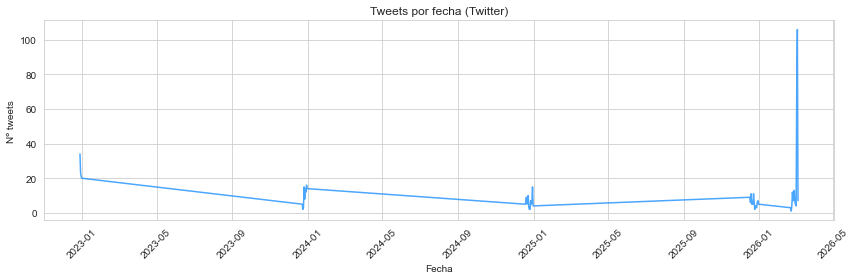

In [17]:
# Visualización temporal: tweets por fecha (Twitter)
df_tw_ts = df_tw.dropna(subset=["created_at"]).copy()
df_tw_ts["fecha"] = df_tw_ts["created_at"].dt.date
por_fecha_tw = df_tw_ts.groupby("fecha").size()
fig, ax = plt.subplots(figsize=(12, 4))
por_fecha_tw.plot(ax=ax, color="dodgerblue", alpha=0.8)
ax.set_title("Tweets por fecha (Twitter)")
ax.set_ylabel("Nº tweets")
ax.set_xlabel("Fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

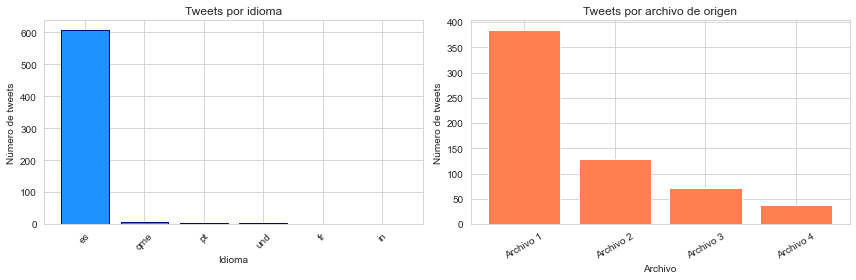

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: tweets por idioma
if "lang" in df_tw.columns:
    lang_counts = df_tw["lang"].value_counts().head(10)
    axes[0].bar(
        lang_counts.index.astype(str),
        lang_counts.values,
        color="dodgerblue",
        edgecolor="navy"
    )
    axes[0].set_title("Tweets por idioma")
    axes[0].set_xlabel("Idioma")
    axes[0].set_ylabel("Número de tweets")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "No hay columna 'lang'", ha="center", va="center")
    axes[0].set_axis_off()

# Gráfico 2: tweets por archivo origen
origen_counts = df_tw["_origen"].value_counts()
origen_labels = [f"Archivo {i+1}" for i in range(len(origen_counts))]

axes[1].bar(
    origen_labels,
    origen_counts.values,
    color="coral"
)
axes[1].set_title("Tweets por archivo de origen")
axes[1].set_xlabel("Archivo")
axes[1].set_ylabel("Número de tweets")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [19]:
# Limpieza Twitter: texto nulo/vacío, duplicados por tweet_id
df_tw = df_tw.dropna(subset=["text"])
df_tw["text"] = df_tw["text"].astype(str).str.strip()
df_tw = df_tw[df_tw["text"].str.len() > 0]
if "tweet_id" in df_tw.columns:
    df_tw = df_tw.drop_duplicates(subset=["tweet_id"], keep="first")
print("Filas tras limpieza:", len(df_tw))

Filas tras limpieza: 557


In [20]:
# Añadir columnas text_clean y emojis (Twitter)
df_tw = add_text_emoji_columns(df_tw, text_col="text")
df_tw[["text", "text_clean", "emojis"]].head(10)

,text,text_clean,emojis
0,Donación de sangre @LevanteUD\n\n🗓️ Jueves #5m...,Donación de sangre @LevanteUD Jueves #5marzo ⏰...,🗓️ 📍 🎁 🐸💙❤️
1,❤️ Ser solidario está en tu mano. ¡Ven a donar...,Ser solidario está en tu mano. ¡Ven a donar sa...,❤️ 📍 🗓 ️ ☎️
2,"La primavera empieza en ti. Dona sangre, dona ...","La primavera empieza en ti. Dona sangre, dona ...",🌱🩸
3,"@Radio_Formula Nada más se andan envenenando, ...","@Radio_Formula Nada más se andan envenenando, ...",
4,Desde Salud impulsan la donación de sangre en ...,Desde Salud impulsan la donación de sangre en ...,
5,#Victoria Realizan intensas campañas de donaci...,#Victoria Realizan intensas campañas de donaci...,
6,El aparcamiento es gratuito en los puntos fijo...,El aparcamiento es gratuito en los puntos fijo...,
7,"𝗔𝗖𝗧𝗨𝗔𝗟𝗜𝗗𝗔𝗗 |\nEl próximo viernes 6 de marzo, c...","| El próximo viernes 6 de marzo, coincidiendo ...",𝗔𝗖𝗧𝗨𝗔𝗟𝗜𝗗𝗔𝗗 🗓️ 📌 🕔
8,LA HERMANDAD VISITA OSSA de MONTIEL.\n\nDonaci...,LA HERMANDAD VISITA OSSA de MONTIEL. Donación ...,
9,@USEmbassyMEX @CruzRoja_MX Será usada para la ...,@USEmbassyMEX @CruzRoja_MX Será usada para la ...,


In [21]:
# Fecha, likes y respuestas (Twitter)
df_tw["fecha"] = pd.to_datetime(df_tw["created_at"], errors="coerce").dt.date
if "like_count" in df_tw.columns:
    df_tw["likes"] = df_tw["like_count"].fillna(0).astype(int)
else:
    df_tw["likes"] = 0
if "reply_count" in df_tw.columns:
    df_tw["respuestas"] = df_tw["reply_count"].fillna(0).astype(int)
else:
    df_tw["respuestas"] = 0

df_tw[["text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].head(10)
# Guardar Twitter procesado
out_tw = BASE / "datos_procesados_twitter.csv"
df_tw.to_csv(out_tw, index=False, encoding="utf-8-sig")
print("Guardado:", out_tw)

Guardado: C:\Users\Usuario\OneDrive - Universidad Pontificia Comillas\SEXTO\TFG\datos_procesados_twitter.csv


Número total de comentarios Twitter: 557


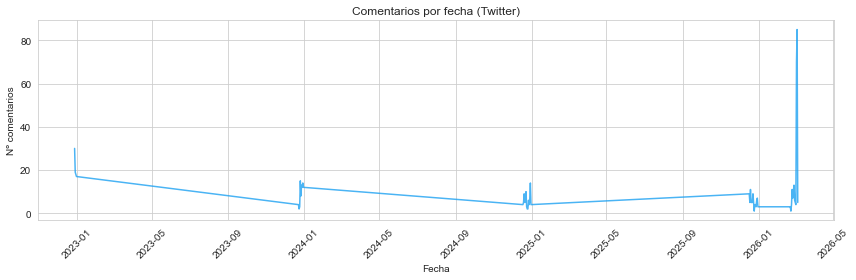

In [22]:
# Resumen Twitter: total y distribución temporal
print(f"Número total de comentarios Twitter: {len(df_tw)}")
df_tw_ts = df_tw.dropna(subset=["fecha"]).copy()
por_fecha_tw = df_tw_ts.groupby("fecha").size()
fig, ax = plt.subplots(figsize=(12, 4))
por_fecha_tw.plot(ax=ax, color="#1DA1F2", alpha=0.8)
ax.set_title("Comentarios por fecha (Twitter)")
ax.set_ylabel("Nº comentarios")
ax.set_xlabel("Fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 4. Reddit
Unimos todos los CSV de comentarios de la carpeta "Reddit scrapping", quitamos duplicados (por comment_id), visualizaciones pertinentes (sin timeline), limpieza y división emojis/texto.

In [23]:
# Unificar CSV de comentarios Reddit (solo archivos de comentarios, no posts ni links)
import pandas as pd

# Unificar CSV de comentarios de Reddit
# Solo se incluyen archivos de comentarios, excluyendo posts y links
carpeta_reddit = BASE / "Reddit scrapping"

excluir = {"reddit_posts", "reddit_links", "reddit_links_only", "reddit_links_step"}
listas_rd = []

for p in carpeta_reddit.glob("*.csv"):
    nombre = p.name.lower()

    # Excluir archivos que no son de comentarios
    if any(x in nombre for x in excluir):
        continue

    try:
        d = pd.read_csv(p)

        # Saltar archivos vacíos
        if d.empty:
            continue

        # Comprobar que exista identificador de comentario
        if "comment_id" not in d.columns:
            continue

        # Unificar columna de texto
        if "body" in d.columns:
            d["text"] = d["body"].astype(str)
        elif "clean_text" in d.columns:
            d["text"] = d["clean_text"].astype(str)
        else:
            continue

        # Asegurar columnas mínimas
        if "post_permalink" not in d.columns:
            d["post_permalink"] = ""

        if "score" not in d.columns:
            d["score"] = pd.NA

        # Convertir created_utc a fecha real si existe
        if "created_utc" in d.columns:
            d["created_date"] = pd.to_datetime(
                d["created_utc"],
                unit="s",
                utc=True,
                errors="coerce"
            )
        else:
            d["created_utc"] = pd.NA
            d["created_date"] = pd.NaT

        # Añadir metadatos
        d["_origen"] = p.name
        d["fuente"] = "reddit"

        listas_rd.append(d)

    except Exception as e:
        print(f"Error leyendo {p.name}: {e}")

# Unir todos los dataframes
if listas_rd:
    df_reddit = pd.concat(listas_rd, ignore_index=True)

    print("Filas antes de quitar duplicados:", len(df_reddit))

    # Eliminar duplicados por comment_id
    df_reddit = df_reddit.drop_duplicates(subset=["comment_id"], keep="first")

    print("Filas tras quitar duplicados:", len(df_reddit))
    display(df_reddit.head())
else:
    print("No se encontraron archivos válidos de comentarios de Reddit.")
    df_reddit = pd.DataFrame()

Error leyendo reddit_comments_v4_robust.csv: No columns to parse from file
Filas antes de quitar duplicados: 1106
Filas tras quitar duplicados: 608


,comment_id,body,score,created_utc,depth,text,post_permalink,created_date,_origen,fuente,clean_text
0,n350r2r,"Yo soy donante de sangre habitual, ya me toca ...",7,1.752524e+09,0.0,"Yo soy donante de sangre habitual, ya me toca ...",,2025-07-14 20:19:36+00:00,comments_single_post.csv,reddit,NaN
1,n352d8u,"Bueno, ya haces mucho más que otros que no pue...",2,1.752525e+09,1.0,"Bueno, ya haces mucho más que otros que no pue...",,2025-07-14 20:27:03+00:00,comments_single_post.csv,reddit,NaN
2,n36igek,si done varias veces a familiares y familiares...,5,1.752541e+09,0.0,si done varias veces a familiares y familiares...,,2025-07-15 00:59:45+00:00,comments_single_post.csv,reddit,NaN
3,n3ggttl,"Gracias por tu comentario. Para mí suerte, nun...",1,1.752678e+09,1.0,"Gracias por tu comentario. Para mí suerte, nun...",,2025-07-16 14:57:14+00:00,comments_single_post.csv,reddit,NaN
4,n39uj3u,Buenas ! Soy donante de sangre y encima 0- que...,3,1.752592e+09,0.0,Buenas ! Soy donante de sangre y encima 0- que...,,2025-07-15 15:07:16+00:00,comments_single_post.csv,reddit,NaN


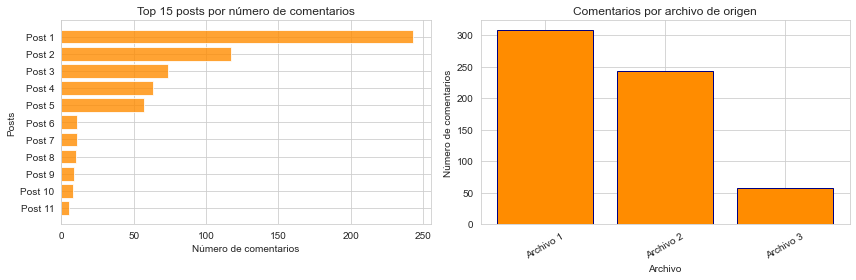

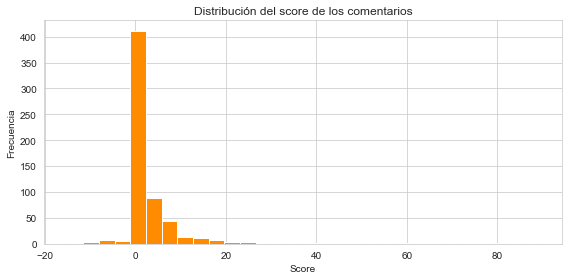

In [24]:
# Visualizaciones Reddit: comentarios por post (top 15), por archivo origen, distribución de score
import matplotlib.pyplot as plt

# Conteos principales
top_posts = df_reddit["post_permalink"].value_counts().head(15)
origen_counts = df_reddit["_origen"].value_counts()

# Etiquetas cortas
post_labels = [f"Post {i+1}" for i in range(len(top_posts))]
origen_labels = [f"Archivo {i+1}" for i in range(len(origen_counts))]

# Figura 1: posts y archivos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top 15 posts por nº comentarios
axes[0].barh(
    post_labels,
    top_posts.values,
    color="darkorange",
    alpha=0.8
)
axes[0].set_title("Top 15 posts por número de comentarios")
axes[0].set_xlabel("Número de comentarios")
axes[0].set_ylabel("Posts")
axes[0].invert_yaxis()

# Comentarios por archivo origen
axes[1].bar(
    origen_labels,
    origen_counts.values,
    color="darkorange",
    edgecolor="navy"
)
axes[1].set_title("Comentarios por archivo de origen")
axes[1].set_xlabel("Archivo")
axes[1].set_ylabel("Número de comentarios")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Figura 2: distribución del score
if "score" in df_reddit.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(
        df_reddit["score"].dropna(),
        bins=30,
        color="darkorange",
        edgecolor="white"
    )
    ax.set_title("Distribución del score de los comentarios")
    ax.set_xlabel("Score")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [25]:
# Limpieza Reddit: texto vacío o nulo
df_reddit = df_reddit.dropna(subset=["text"])
df_reddit["text"] = df_reddit["text"].astype(str).str.strip()
df_reddit = df_reddit[df_reddit["text"].str.len() > 0]
print("Filas tras limpieza:", len(df_reddit))

Filas tras limpieza: 608


In [26]:
# Fecha, likes y respuestas (Reddit; no hay likes/respuestas por comentario)
if "created_utc" in df_reddit.columns:
    df_reddit["fecha"] = pd.to_datetime(df_reddit["created_utc"], unit="s", errors="coerce").dt.date
elif "created_date" in df_reddit.columns:
    df_reddit["fecha"] = pd.to_datetime(df_reddit["created_date"], errors="coerce").dt.date
else:
    df_reddit["fecha"] = pd.NaT
df_reddit["likes"] = 0
df_reddit["respuestas"] = 0

# Añadir columnas text_clean y emojis (Reddit)
df_reddit = add_text_emoji_columns(df_reddit, text_col="text")
df_reddit[["text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].head(10)

,text,text_clean,emojis,fecha,likes,respuestas
0,"Yo soy donante de sangre habitual, ya me toca ...","Yo soy donante de sangre habitual, ya me toca ...",,2025-07-14,0,0
1,"Bueno, ya haces mucho más que otros que no pue...","Bueno, ya haces mucho más que otros que no pue...",,2025-07-14,0,0
2,si done varias veces a familiares y familiares...,si done varias veces a familiares y familiares...,,2025-07-15,0,0
3,"Gracias por tu comentario. Para mí suerte, nun...","Gracias por tu comentario. Para mí suerte, nun...",,2025-07-16,0,0
4,Buenas ! Soy donante de sangre y encima 0- que...,Buenas ! Soy donante de sangre y encima 0- que...,😂,2025-07-15,0,0
5,Qué bueno. Realmente creo que tienes mucho val...,Qué bueno. Realmente creo que tienes mucho val...,,2025-07-16,0,0
6,"No puedo. En cambio, he recibido sangre y órga...","No puedo. En cambio, he recibido sangre y órga...",,2025-07-15,0,0
7,Pues tu comentario me parece una motivación y ...,Pues tu comentario me parece una motivación y ...,,2025-07-16,0,0
8,Yo no me he muerto en ninguna de las veces que...,Yo no me he muerto en ninguna de las veces que...,,2025-07-15,0,0
9,Pues tienes razón. Realmente me parece un come...,Pues tienes razón. Realmente me parece un come...,,2025-07-16,0,0


In [27]:
# Guardar Reddit procesado
out_reddit = BASE / "datos_procesados_reddit.csv"
df_reddit.to_csv(out_reddit, index=False, encoding="utf-8-sig")
print("Guardado:", out_reddit)

Guardado: C:\Users\Usuario\OneDrive - Universidad Pontificia Comillas\SEXTO\TFG\datos_procesados_reddit.csv


Número total de comentarios Reddit: 608


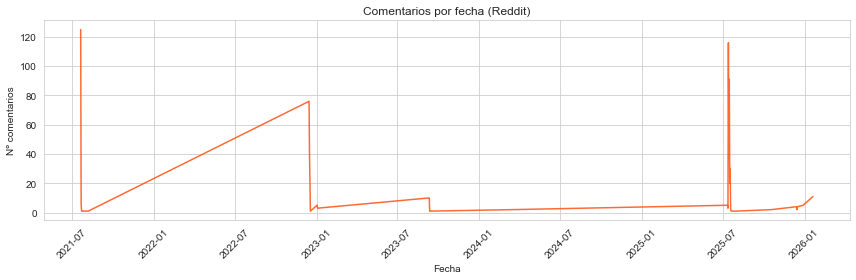

In [28]:
# Resumen Reddit: total y distribución temporal
print(f"Número total de comentarios Reddit: {len(df_reddit)}")
df_rd_ts = df_reddit.dropna(subset=["fecha"]).copy()
if len(df_rd_ts) > 0:
    por_fecha_rd = df_rd_ts.groupby("fecha").size()
    fig, ax = plt.subplots(figsize=(12, 4))
    por_fecha_rd.plot(ax=ax, color="#ff4500", alpha=0.8)
    ax.set_title("Comentarios por fecha (Reddit)")
    ax.set_ylabel("Nº comentarios")
    ax.set_xlabel("Fecha")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No hay fechas para graficar.")


---
## 5. Resumen y datos listos para análisis
Resumen por fuente y opcionalmente un DataFrame unificado (para cuando quieras hacer análisis conjunto).

In [29]:
# Resumen por fuente
resumen = pd.DataFrame({
    "fuente": ["instagram", "tiktok", "twitter", "reddit"],
    "filas": [len(df_ig), len(df_tiktok), len(df_tw), len(df_reddit)],
})
print(resumen.to_string(index=False))
print("\nArchivos guardados en la raíz del TFG:")
for n in ["datos_procesados_instagram.csv", "datos_procesados_tiktok.csv", "datos_procesados_twitter.csv", "datos_procesados_reddit.csv"]:
    p = BASE / n
    print(" ", p.name, "->", len(pd.read_csv(p)), "filas")

   fuente  filas
instagram   1303
   tiktok    736
  twitter    557
   reddit    608

Archivos guardados en la raíz del TFG:
  datos_procesados_instagram.csv -> 1303 filas
  datos_procesados_tiktok.csv -> 736 filas
  datos_procesados_twitter.csv -> 557 filas
  datos_procesados_reddit.csv -> 608 filas


In [30]:
# (Opcional) Unión de todas las fuentes para análisis posterior
# Columnas comunes: fuente, text, text_clean, emojis, fecha, likes, respuestas
def fila_minima_ig(df):
    return df[["fuente", "text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].copy()
def fila_minima_tiktok(df):
    return df[["fuente", "text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].copy()
def fila_minima_tw(df):
    return df[["fuente", "text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].copy()
def fila_minima_reddit(df):
    return df[["fuente", "text", "text_clean", "emojis", "fecha", "likes", "respuestas"]].copy()

union_ig = fila_minima_ig(df_ig)
union_tk = fila_minima_tiktok(df_tiktok)
union_tw = fila_minima_tw(df_tw)
union_rd = fila_minima_reddit(df_reddit)
df_union = pd.concat([union_ig, union_tk, union_tw, union_rd], ignore_index=True)
df_union.to_csv(BASE / "datos_procesados_union_todas_fuentes.csv", index=False, encoding="utf-8-sig")
print("Unión guardada: datos_procesados_union_todas_fuentes.csv —", len(df_union), "filas")
df_union["fuente"].value_counts()

Unión guardada: datos_procesados_union_todas_fuentes.csv — 3204 filas


fuente
instagram    1303
tiktok        736
reddit        608
twitter       557
Name: count, dtype: int64

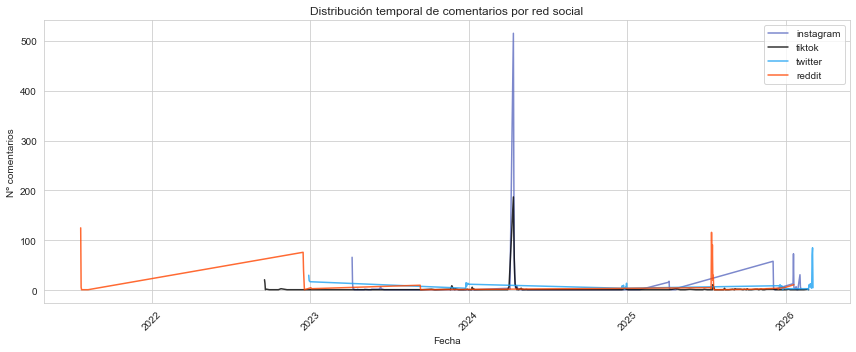

In [31]:
# Gráfica: distribución temporal de comentarios por RRSS (colores por red)
df_union_ts = df_union.dropna(subset=["fecha"]).copy()
if len(df_union_ts) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colores = {"instagram": "#5c6bc0", "tiktok": "#000000", "twitter": "#1DA1F2", "reddit": "#ff4500"}
    for fuente in df_union_ts["fuente"].unique():
        mask = df_union_ts["fuente"] == fuente
        por_fecha = df_union_ts.loc[mask].groupby("fecha").size()
        color = colores.get(fuente, "gray")
        por_fecha.plot(ax=ax, label=fuente, color=color, alpha=0.8)
    ax.set_title("Distribución temporal de comentarios por red social")
    ax.set_ylabel("Nº comentarios")
    ax.set_xlabel("Fecha")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No hay fechas para graficar.")


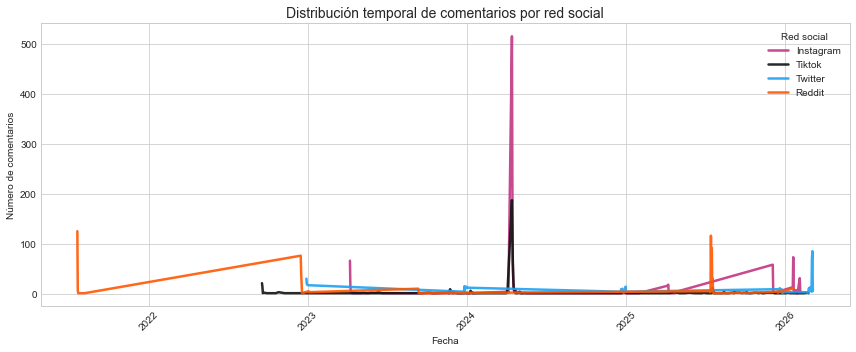

In [32]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-whitegrid")

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))

    colores = {
        "instagram": "#C13584",
        "tiktok": "#111111",
        "twitter": "#1DA1F2",
        "reddit": "#FF5700"
    }

    for fuente in df_union_ts["fuente"].unique():
        mask = df_union_ts["fuente"] == fuente
        por_fecha = df_union_ts.loc[mask].groupby("fecha").size()
        color = colores.get(fuente, "gray")

        ax.plot(
            por_fecha.index.to_numpy(),
            por_fecha.to_numpy(),
            label=fuente.capitalize(),
            color=color,
            linewidth=2.5,
            alpha=0.9
        )

    ax.set_title("Distribución temporal de comentarios por red social", fontsize=14)
    ax.set_ylabel("Número de comentarios")
    ax.set_xlabel("Fecha")

    ax.legend(title="Red social")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("No hay fechas para graficar.")

In [33]:
import matplotlib.pyplot as plt
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

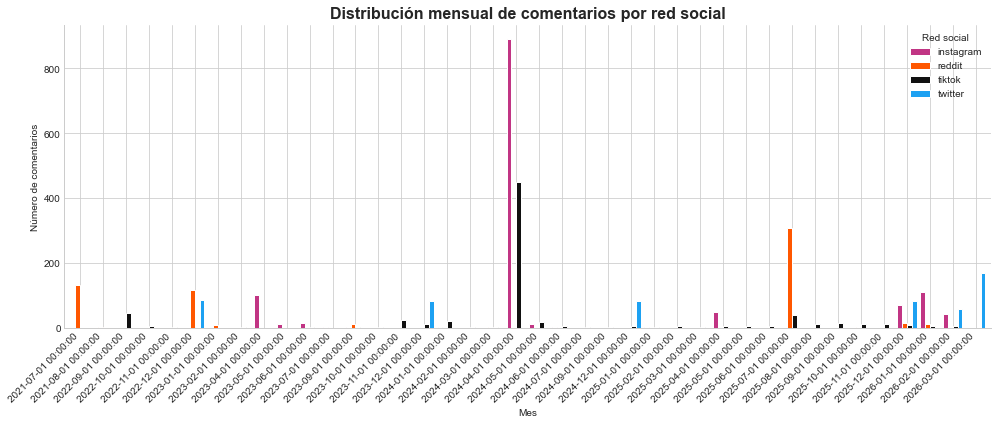

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-whitegrid")

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
    df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

    colores = {
        "instagram": "#C13584",
        "tiktok": "#111111",
        "twitter": "#1DA1F2",
        "reddit": "#FF5700"
    }

    tabla = (
        df_union_ts.groupby(["mes", "fuente"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    tabla.plot(
        kind="bar",
        ax=ax,
        width=0.85,
        color=[colores.get(col, "gray") for col in tabla.columns]
    )

    ax.set_title("Distribución mensual de comentarios por red social", fontsize=16, weight="bold")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Número de comentarios")
    ax.legend(title="Red social", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

else:
    print("No hay fechas para graficar.")

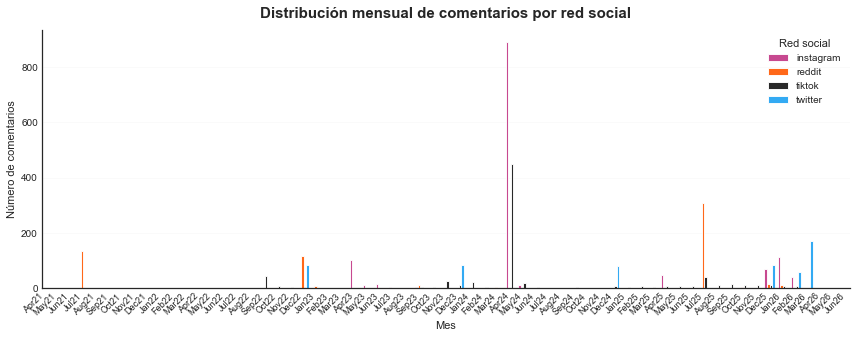

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-white")

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
    df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

    colores = {
        "instagram": "#C13584",
        "reddit": "#FF5700",
        "tiktok": "#111111",
        "twitter": "#1DA1F2"
    }

    tabla = (
        df_union_ts.groupby(["mes", "fuente"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    # Reordenar columnas si existen
    orden = ["instagram", "reddit", "tiktok", "twitter"]
    columnas = [c for c in orden if c in tabla.columns]
    tabla = tabla[columnas]

    fig, ax = plt.subplots(figsize=(12, 4.8))

    x = tabla.index.to_pydatetime()
    width = 6  # ancho de barras en días aprox

    n = len(tabla.columns)
    offsets = {
        1: [0],
        2: [-width/2, width/2],
        3: [-width, 0, width],
        4: [-1.5*width, -0.5*width, 0.5*width, 1.5*width]
    }

    for i, col in enumerate(tabla.columns):
        x_shifted = [fecha + pd.Timedelta(days=offsets[n][i]) for fecha in x]
        ax.bar(
            x_shifted,
            tabla[col].to_numpy(),
            width=width,
            label=col,
            color=colores.get(col, "gray"),
            alpha=0.9
        )

    ax.set_title("Distribución mensual de comentarios por red social", fontsize=15, weight="bold", pad=12)
    ax.set_xlabel("Mes", fontsize=11)
    ax.set_ylabel("Número de comentarios", fontsize=11)

    # Formato del eje X: Oct23, Nov23...
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=10)

    # Cuadrícula muy suave solo en Y
    ax.grid(axis="y", linestyle="-", alpha=0.12)
    ax.grid(axis="x", visible=False)

    # Quitar bordes innecesarios
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Leyenda más discreta
    ax.legend(title="Red social", frameon=False, fontsize=10, title_fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print("No hay fechas para graficar.")

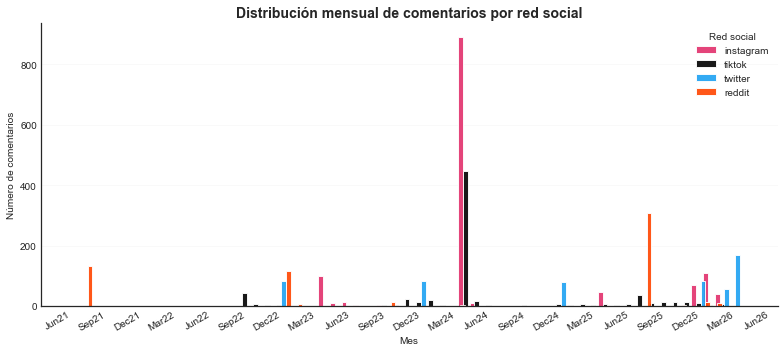

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-white")

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
    df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

    colores = {
        "instagram": "#E1306C",
        "tiktok": "#000000",
        "twitter": "#1DA1F2",
        "reddit": "#FF4500"
    }

    tabla = (
        df_union_ts.groupby(["mes", "fuente"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    orden = ["instagram", "tiktok", "twitter", "reddit"]
    tabla = tabla[[c for c in orden if c in tabla.columns]]

    fig, ax = plt.subplots(figsize=(11,5))

    x = tabla.index.to_pydatetime()
    width = 12  # barras más anchas

    offsets = [-18, -6, 6, 18]

    for i, col in enumerate(tabla.columns):
        x_shifted = [fecha + pd.Timedelta(days=offsets[i]) for fecha in x]

        ax.bar(
            x_shifted,
            tabla[col].to_numpy(),
            width=width,
            color=colores[col],
            label=col,
            alpha=0.9
        )

    ax.set_title("Distribución mensual de comentarios por red social", fontsize=14, weight="bold")
    ax.set_ylabel("Número de comentarios")
    ax.set_xlabel("Mes")

    # SOLO mostrar una etiqueta cada 3 meses
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))

    plt.xticks(rotation=30, ha="right")

    # cuadrícula muy suave
    ax.grid(axis="y", alpha=0.15)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(title="Red social", frameon=False)

    plt.tight_layout()
    plt.show()

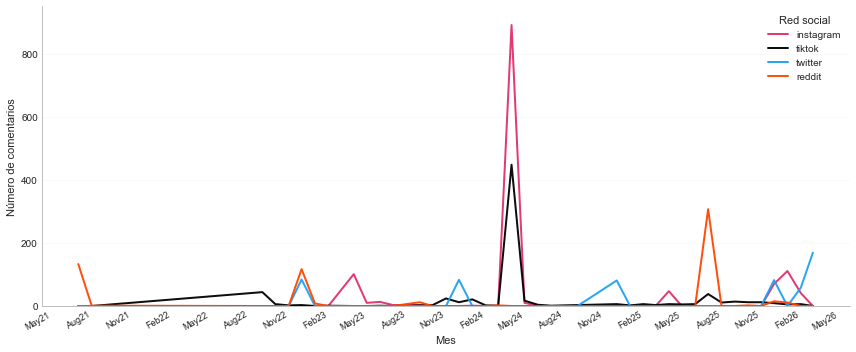

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-white")

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
    df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

    colores = {
        "instagram": "#E1306C",  # fucsia Instagram
        "tiktok": "#000000",     # negro TikTok
        "twitter": "#1DA1F2",    # azul X/Twitter
        "reddit": "#FF4500"      # rojo Reddit
    }

    tabla = (
        df_union_ts.groupby(["mes", "fuente"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    orden = ["instagram", "tiktok", "twitter", "reddit"]
    columnas = [c for c in orden if c in tabla.columns]
    tabla = tabla[columnas]

    fig, ax = plt.subplots(figsize=(12, 5))

    for col in tabla.columns:
        x = tabla.index.to_pydatetime()
        y = tabla[col].to_numpy()

        ax.plot(
            x,
            y,
            label=col,
            color=colores.get(col, "gray"),
            linewidth=2,
            alpha=0.95
        )

    #ax.set_title("Evolución mensual de comentarios por red social", fontsize=14, weight="bold", pad=12)
    ax.set_xlabel("Mes", fontsize=11)
    ax.set_ylabel("Número de comentarios", fontsize=11)

    # Mostrar una marca cada 3 meses
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.yticks(fontsize=10)

    # Cuadrícula muy suave solo horizontal
    ax.grid(axis="y", alpha=0.15, linestyle="-")
    ax.grid(axis="x", visible=False)

    # Quitar bordes innecesarios
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Leyenda limpia
    ax.legend(title="Red social", frameon=False, fontsize=10, title_fontsize=11)

    ax.spines["left"].set_color("#B0B0B0")
    ax.spines["bottom"].set_color("#B0B0B0")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.set_ylim(0, 950)
    
    plt.tight_layout()
    plt.show()

else:
    print("No hay fechas para graficar.")

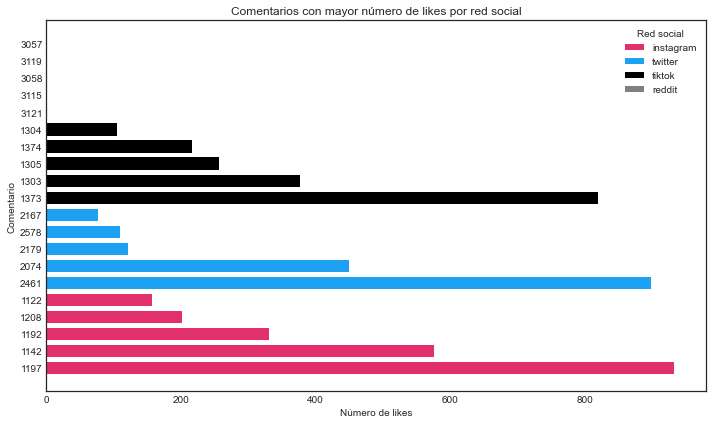

In [56]:
# Top comentarios con más likes por red social

if "likes" in df_union.columns:

    top_comments = (
        df_union.sort_values("likes", ascending=False)
        .groupby("fuente")
        .head(5)
    )

    fig, ax = plt.subplots(figsize=(10,6))

    colores = {
        "instagram": "#E1306C",
        "tiktok": "#000000",
        "twitter": "#1DA1F2",
        "reddit": "#FF4500"
    }

    for fuente in top_comments["fuente"].unique():

        data = top_comments[top_comments["fuente"] == fuente]

        ax.barh(
            data.index.astype(str),
            data["likes"],
            color=colores.get(fuente, "gray"),
            label=fuente
        )

    ax.set_title("Comentarios con mayor número de likes por red social")
    ax.set_xlabel("Número de likes")
    ax.set_ylabel("Comentario")

    ax.legend(title="Red social")

    plt.tight_layout()
    plt.show()

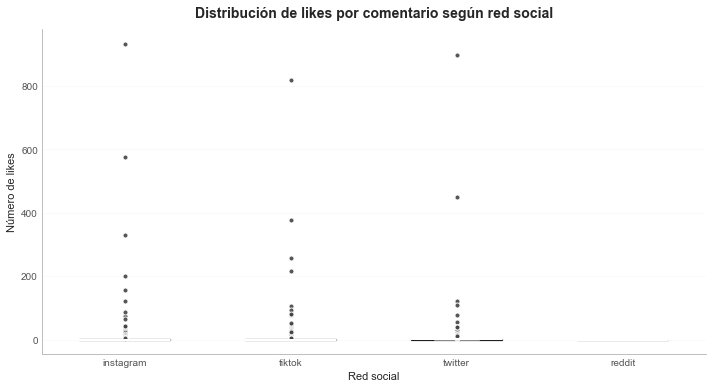

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar datos válidos
df_likes = df_union.dropna(subset=["fuente", "likes"]).copy()

# Colores por red social
palette = {
    "instagram": "#E1306C",  # fucsia
    "tiktok": "#000000",     # negro
    "twitter": "#1DA1F2",    # azul
    "reddit": "#FF4500"      # rojo
}

# Orden de aparición
orden = [x for x in ["instagram", "tiktok", "twitter", "reddit"] if x in df_likes["fuente"].unique()]

plt.style.use("seaborn-white")
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(
    data=df_likes,
    x="fuente",
    y="likes",
    order=orden,
    palette=palette,
    width=0.55,
    linewidth=1.2,
    showcaps=True,
    boxprops={"alpha": 0.85},
    whiskerprops={"color": "#888888", "linewidth": 1},
    capprops={"color": "#888888", "linewidth": 1},
    medianprops={"color": "white", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#444444",
        "markeredgecolor": "white",
        "markersize": 5,
        "alpha": 0.9
    },
    ax=ax
)

ax.set_title("Distribución de likes por comentario según red social", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Red social", fontsize=11)
ax.set_ylabel("Número de likes", fontsize=11)

# Estética más limpia
ax.grid(axis="y", alpha=0.12)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B0B0B0")
ax.spines["bottom"].set_color("#B0B0B0")
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis='x', colors='#555555')
ax.tick_params(axis='y', colors='#555555')

plt.tight_layout()
plt.show()

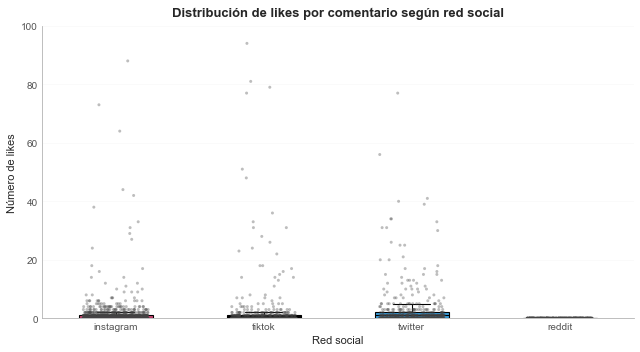

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_likes = df_union.dropna(subset=["fuente", "likes"]).copy()

palette = {
    "instagram": "#E1306C",
    "tiktok": "#000000",
    "twitter": "#1DA1F2",
    "reddit": "#FF4500"
}

orden = [x for x in ["instagram", "tiktok", "twitter", "reddit"] if x in df_likes["fuente"].unique()]

plt.style.use("seaborn-white")
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df_likes,
    x="fuente",
    y="likes",
    order=orden,
    palette=palette,
    width=0.5,
    linewidth=1.1,
    showfliers=False,   # quitamos outliers del gráfico principal
    ax=ax
)

# Opcional: añadir puntitos pequeños con jitter
sns.stripplot(
    data=df_likes[df_likes["likes"] <= 100],
    x="fuente",
    y="likes",
    order=orden,
    color="#444444",
    alpha=0.35,
    size=3,
    jitter=0.22,
    ax=ax
)

ax.set_title("Distribución de likes por comentario según red social", fontsize=13, weight="bold", pad=10)
ax.set_xlabel("Red social", fontsize=11)
ax.set_ylabel("Número de likes", fontsize=11)

# limitar eje Y para ver la parte central
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.10)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B0B0B0")
ax.spines["bottom"].set_color("#B0B0B0")
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(axis="x", colors="#555555")
ax.tick_params(axis="y", colors="#555555")

plt.tight_layout()
plt.show()

In [58]:
outliers_list = []

for fuente in orden:
    sub = df_likes[df_likes["fuente"] == fuente].copy()

    q1 = sub["likes"].quantile(0.25)
    q3 = sub["likes"].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr

    outliers = sub[sub["likes"] > limite_superior].copy()
    outliers["limite_superior"] = limite_superior

    outliers_list.append(outliers)

df_outliers = pd.concat(outliers_list, ignore_index=True)

df_outliers = df_outliers.sort_values(["fuente", "likes"], ascending=[True, False])

print(df_outliers[["fuente", "likes"]].head(20))

        fuente  likes
102  instagram    932
86   instagram    575
99   instagram    331
107  instagram    201
83   instagram    157
103  instagram    122
97   instagram     88
28   instagram     73
29   instagram     64
101  instagram     44
88   instagram     42
87   instagram     38
25   instagram     33
3    instagram     31
27   instagram     29
24   instagram     27
72   instagram     24
96   instagram     18
20   instagram     17
10   instagram     16


In [63]:
tabla_comentarios = top_outliers[
    ["fuente", "fecha", "likes", "text"]
].sort_values("likes", ascending=False)

tabla_comentarios

,fuente,fecha,likes,text
102,instagram,2024-04-13,932,Los de la generación de cristal no pueden dona...
229,twitter,2025-12-23,897,cada vez que veo una persona anti vacunas pien...
135,tiktok,2024-04-13,819,yo me acuerdo que a la enfermera casi le da un...
86,instagram,2024-04-13,575,Cuanta razón tienes! A mi me salvó hace dos dí...
187,twitter,2026-03-04,449,Tú al igual que nuestro ministro consejero Mar...
122,tiktok,2023-12-09,377,Q tiene q ver el piercing con donar sangre ?
99,instagram,2024-04-13,331,Jajajajaja. Estaba esperando el momento del de...
124,tiktok,2023-11-23,257,me quedé sola a traición
136,tiktok,2024-04-13,217,"me encanta el "" ansiedad ""🤣🤣🤣"
107,instagram,2024-04-13,201,En los 80 la llevaba yo mismo la sangre en una...


In [66]:
top_comments = df_union.sort_values("likes", ascending=False).head(10)

tabla_top = top_comments[
    ["fuente", "fecha", "likes", "text"]
]

tabla_top

,fuente,fecha,likes,text
1197,instagram,2024-04-13,932,Los de la generación de cristal no pueden dona...
2461,twitter,2025-12-23,897,cada vez que veo una persona anti vacunas pien...
1373,tiktok,2024-04-13,819,yo me acuerdo que a la enfermera casi le da un...
1142,instagram,2024-04-13,575,Cuanta razón tienes! A mi me salvó hace dos dí...
2074,twitter,2026-03-04,449,Tú al igual que nuestro ministro consejero Mar...
1303,tiktok,2023-12-09,377,Q tiene q ver el piercing con donar sangre ?
1192,instagram,2024-04-13,331,Jajajajaja. Estaba esperando el momento del de...
1305,tiktok,2023-11-23,257,me quedé sola a traición
1374,tiktok,2024-04-13,217,"me encanta el "" ansiedad ""🤣🤣🤣"
1208,instagram,2024-04-13,201,En los 80 la llevaba yo mismo la sangre en una...


In [73]:
tabla_top.to_csv("tabla_top_comentarios.csv", index=False, encoding="utf-8")

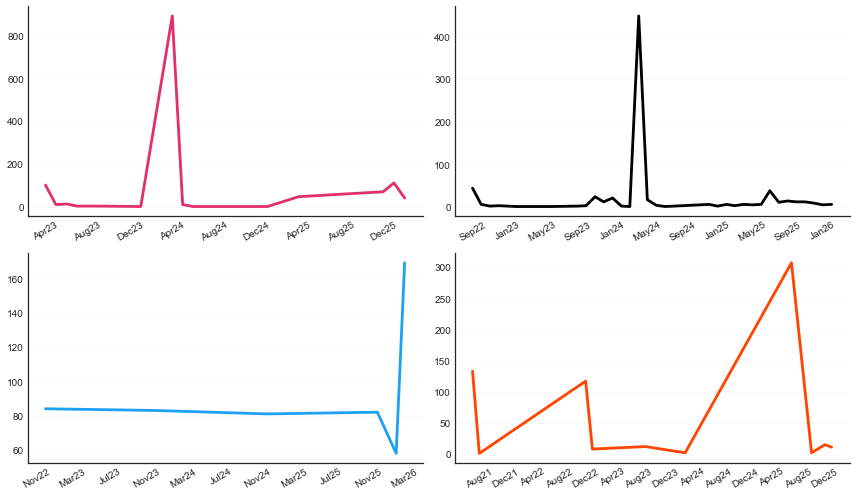

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_union_ts = df_union.dropna(subset=["fecha"]).copy()

df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

colores = {
    "instagram": "#E1306C",
    "tiktok": "#000000",
    "twitter": "#1DA1F2",
    "reddit": "#FF4500"
}

redes = ["instagram", "tiktok", "twitter", "reddit"]

fig, axes = plt.subplots(2, 2, figsize=(12,7))
axes = axes.flatten()

for ax, red in zip(axes, redes):

    datos = df_union_ts[df_union_ts["fuente"] == red]

    if len(datos) > 0:

        conteo = datos.groupby("mes").size()

        ax.plot(
            conteo.index.to_numpy(),
            conteo.to_numpy(),
            color=colores[red],
            linewidth=2.8,
        )

    ## ax.set_title(red.capitalize(), fontsize=11)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))

    ax.grid(axis="y", alpha=0.12)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=30)

## fig.suptitle("Evolución temporal de comentarios por red social", fontsize=14)

plt.tight_layout()
plt.show()

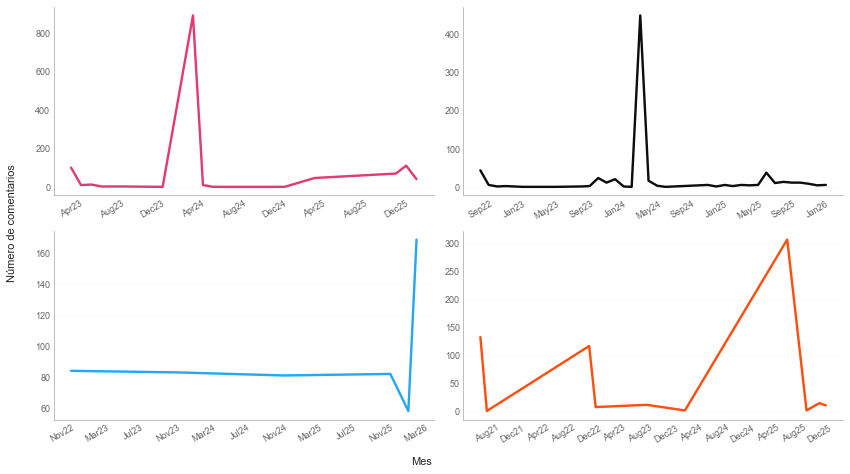

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Copia con fechas válidas
df_union_ts = df_union.dropna(subset=["fecha"]).copy()

if len(df_union_ts) > 0:
    df_union_ts["fecha"] = pd.to_datetime(df_union_ts["fecha"])
    df_union_ts["mes"] = df_union_ts["fecha"].dt.to_period("M").dt.to_timestamp()

    # Colores típicos de cada red social
    colores = {
        "instagram": "#E1306C",
        "tiktok": "#000000",
        "twitter": "#1DA1F2",
        "reddit": "#FF4500"
    }

    redes = ["instagram", "tiktok", "twitter", "reddit"]

    plt.style.use("seaborn-white")
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, red in zip(axes, redes):
        datos = df_union_ts[df_union_ts["fuente"] == red]

        if len(datos) > 0:
            conteo = datos.groupby("mes").size().sort_index()

            ax.plot(
                conteo.index.to_numpy(),
                conteo.to_numpy(),
                color=colores.get(red, "gray"),
                linewidth=2.4,
                alpha=0.95
            )

        ## ax.set_title(red.capitalize(), fontsize=11)

        # Eje X más limpio
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b%y"))

        # Cuadrícula suave solo horizontal
        ax.grid(axis="y", alpha=0.08)
        ax.grid(axis="x", visible=False)

        # Ejes finitos y grisáceos
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#B0B0B0")
        ax.spines["bottom"].set_color("#B0B0B0")
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        # Ticks más discretos
        ax.tick_params(axis="x", colors="#666666", rotation=30, labelsize=9)
        ax.tick_params(axis="y", colors="#666666", labelsize=9)

        ax.set_xlabel("")
        ax.set_ylabel("")

    ## fig.suptitle("Evolución temporal de comentarios por red social", fontsize=14, y=0.98)
    fig.text(0.5, 0.02, "Mes", ha="center", fontsize=11)
    fig.text(0.02, 0.5, "Número de comentarios", va="center", rotation="vertical", fontsize=11)

    plt.tight_layout(rect=[0.04, 0.04, 1, 0.95])
    plt.show()

else:
    print("No hay fechas para graficar.")